In [1]:
import yt
import numpy as np
import matplotlib.pyplot as plt
import silmaril

In [2]:
epf = [
    ("particle_family", "b"),
    ("particle_tag", "b"),
    ("particle_birth_epoch", "d"),
    ("particle_metallicity", "d"),
]

ds = yt.load('data/output_00273/info_00273.txt', extra_particle_fields = epf)
ad = ds.all_data()

yt : [INFO     ] 2025-04-14 17:31:38,604 Parameters: current_time              = 4.311420483661945
yt : [INFO     ] 2025-04-14 17:31:38,607 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2025-04-14 17:31:38,608 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-04-14 17:31:38,609 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-04-14 17:31:38,610 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-04-14 17:31:38,610 Parameters: current_redshift          = 12.171087046255657
yt : [INFO     ] 2025-04-14 17:31:38,611 Parameters: omega_lambda              = 0.685000002384186
yt : [INFO     ] 2025-04-14 17:31:38,612 Parameters: omega_matter              = 0.314999997615814
yt : [INFO     ] 2025-04-14 17:31:38,613 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-04-14 17:31:38,614 Parameters: hubble_constant           = 0.674000015258789
yt : [INFO     ] 2025-04-14 17:31:38,626 Detected RAMSES-RT 

In [3]:
x = np.array(ad["star", "particle_position_x"])
y = np.array(ad["star", "particle_position_y"])
z = np.array(ad["star", "particle_position_z"])
ctr = np.array([np.mean(x), np.mean(y), np.mean(z)])

In [4]:
sp = ds.sphere(ctr, (800, "pc"))
pw = 400

yt : [INFO     ] 2025-04-14 17:31:44,501 Projection completed
yt : [INFO     ] 2025-04-14 17:31:44,503 xlim = 0.491120 0.491223
yt : [INFO     ] 2025-04-14 17:31:44,504 ylim = 0.492725 0.492828
yt : [INFO     ] 2025-04-14 17:31:44,507 xlim = 0.491120 0.491223
yt : [INFO     ] 2025-04-14 17:31:44,509 ylim = 0.492725 0.492828
yt : [INFO     ] 2025-04-14 17:31:44,513 Making a fixed resolution buffer of (('gas', 'density')) 800 by 800



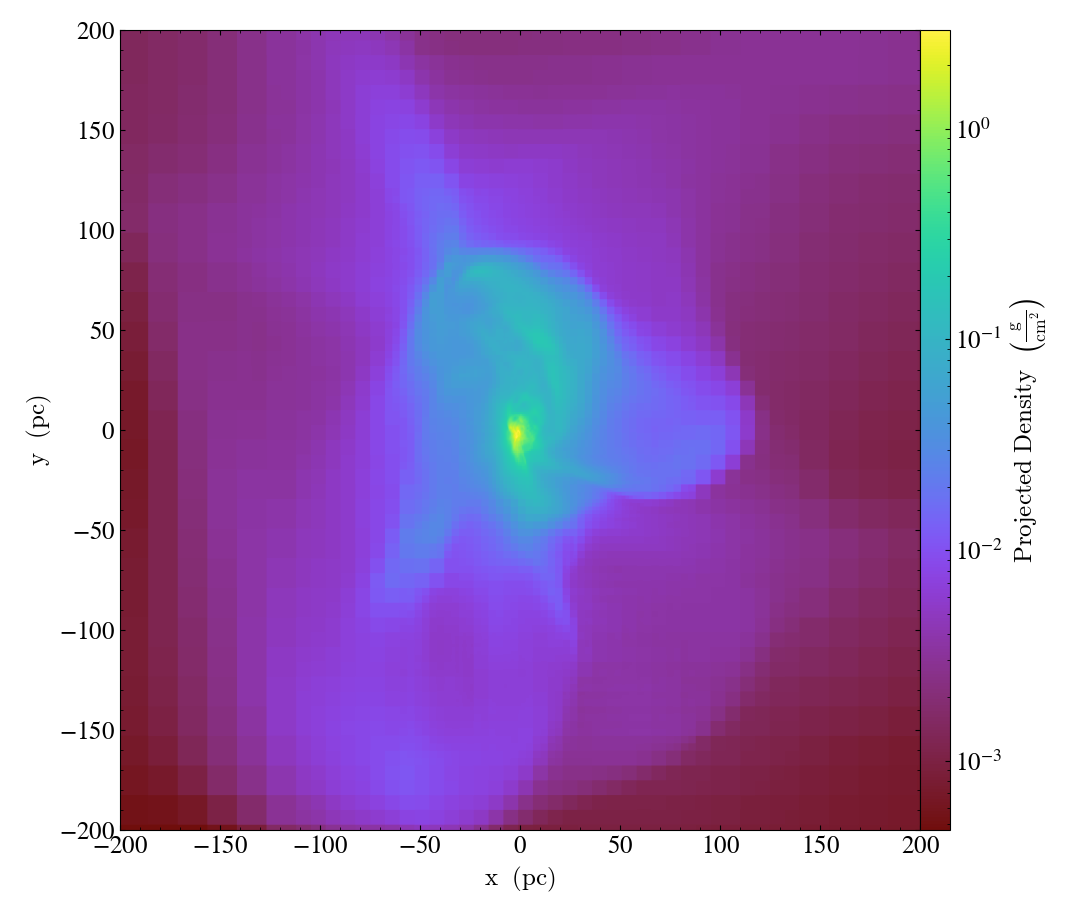

In [5]:
p1 = yt.ProjectionPlot(ds, "z", ("gas", "density"), data_source = sp, width = (pw, "pc"), center = ctr)
p1.show()

yt : [INFO     ] 2025-04-14 17:31:46,212 Projection completed
yt : [INFO     ] 2025-04-14 17:31:46,213 xlim = 0.491120 0.491223
yt : [INFO     ] 2025-04-14 17:31:46,214 ylim = 0.492725 0.492828
yt : [INFO     ] 2025-04-14 17:31:46,217 xlim = 0.491120 0.491223
yt : [INFO     ] 2025-04-14 17:31:46,218 ylim = 0.492725 0.492828
yt : [INFO     ] 2025-04-14 17:31:46,219 Making a fixed resolution buffer of (('gas', 'temperature')) 800 by 800



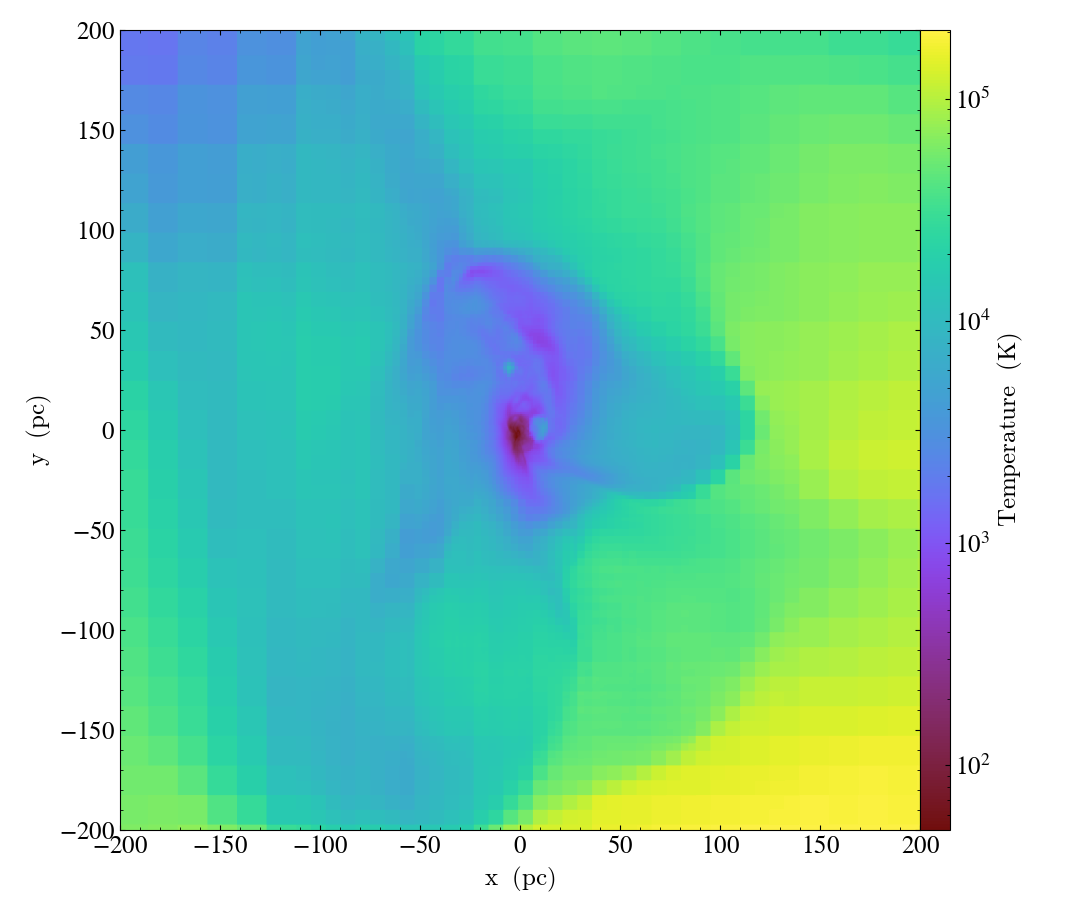

In [6]:
p2 = yt.ProjectionPlot(ds, "z", ("gas", "temperature"), weight_field = ("gas", "density"), data_source = sp, width = (pw, "pc"), center = ctr)
p2.show()

In [10]:
@yt.derived_field(name = ("star", "stellar_ages"), units = "Myr", sampling_type = "particle", force_override = True)
def _age(field, data):
    time = data.ds.current_time.in_units("Myr").value

    cgs_yr = 3.1556926e7  # 1yr (in s)
    cgs_pc = 3.08567758e18  # pc (in cm)
    h_0 = data.ds.hubble_constant * 100 # hubble parameter (km/s/Mpc)
    h_0_invsec = h_0 * 1e5 / (1e6 * cgs_pc)  # hubble constant h [km/s Mpc-1]->[1/sec]
    h_0inv_yr = 1 / h_0_invsec / cgs_yr  # 1/h_0 [yr]
    star_age_myr = np.array(data["star", "particle_birth_epoch"]) * h_0inv_yr / 1e6 + 13700

    ages = time - star_age_myr
    return data.ds.arr(ages, "Myr")

ds.add_field(("star", "stellar_ages"), function = _age, units = "Myr", sampling_type = "particle", force_override = True)

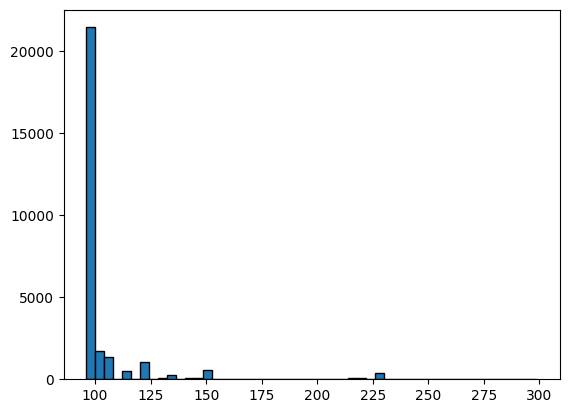

In [11]:
new_stellar_ages = np.array(ad["star", "stellar_ages"])
plt.hist(new_stellar_ages, bins = 50, edgecolor ="Black")
plt.show()

In [13]:
@yt.derived_field(name = ("star", "lum"), sampling_type = "particle", force_override = True)
def _lum(field, data):
    z = data.ds.current_redshift

    unique_ages = np.unique(np.array(data["star", "stellar_ages"]))

    lum = {}
    for s in unique_ages:
        lum.update({s : silmaril.galaxy.lum_lookup_filtered(s, z, None)})

    ret = []
    for a in data["star", "stellar_ages"]:
        ret.append(lum.get(a))

    return ret

ds.add_field(("star", "lum"), function = _lum, sampling_type = "particle", force_override = True)

TypeError: unhashable type: 'unyt_quantity'